# 🌿 Plant Disease Classification — Solution Complète FIXED


In [1]:
# ═══════════════════════════════════════════
#  CELLULE 1 — GPU + Installation
# ═══════════════════════════════════════════
!nvidia-smi
!pip install timm -q


Fri Mar 27 02:42:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ═══════════════════════════════════════════
#  CELLULE 2 — Imports
# ═══════════════════════════════════════════
import os, json, random, warnings
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import timm

warnings.filterwarnings('ignore')

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')


✅ Device: cuda


In [3]:
# ═══════════════════════════════════════════
#  CELLULE 4 — Configuration
# ═══════════════════════════════════════════
class CFG:
    DATA_DIR = '/kaggle/input/competitions/ai-camp-2-03'
    IMG_SIZE    = 224
    BATCH_SIZE  = 32
    EPOCHS      = 50
    LR          = 1e-3
    WEIGHT_DECAY= 1e-4
    NUM_WORKERS = 2
    SEED        = 42
    AMP         = True
    MODEL_NAME  = 'efficientnet_b3'

print('✅ Config OK')


✅ Config OK


In [4]:
# ═══════════════════════════════════════════
#  CELLULE 5 — Chargement des données
# ═══════════════════════════════════════════

# Détecter la structure des dossiers
def find_train_dir(base):
    for root, dirs, files in os.walk(base):
        if 'train' in dirs:
            return os.path.join(root, 'train')
    return None

train_path = find_train_dir(CFG.DATA_DIR)
print(f'Train path: {train_path}')

# Créer label mapping depuis les dossiers
classes  = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
label2id = {cls: idx for idx, cls in enumerate(classes)}
id2label = {idx: cls for cls, idx in label2id.items()}
NUM_CLASSES = len(classes)
print(f'✅ {NUM_CLASSES} classes trouvées')

# Construire train DataFrame
train_data = []
for class_name, label_id in label2id.items():
    class_dir = os.path.join(train_path, class_name)
    for img_name in os.listdir(class_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            train_data.append({
                'id': img_name,
                'filepath': os.path.join(train_path, class_name, img_name),
                'label_id': label_id,
                'class_name': class_name
            })
train_df = pd.DataFrame(train_data)
print(f'✅ Train: {len(train_df)} images')

# Charger test.csv
test_csv_path = None
for root, dirs, files in os.walk(CFG.DATA_DIR):
    for f in files:
        if f == 'test.csv':
            test_csv_path = os.path.join(root, f)
test_df = pd.read_csv(test_csv_path)

# Trouver le dossier test
def find_test_dir(base):
    for root, dirs, files in os.walk(base):
        if 'test' in dirs:
            return os.path.join(root, 'test')
    return None

test_path = find_test_dir(CFG.DATA_DIR)
print(f'Test path: {test_path}')

# Construire le filepath complet pour le test
def build_test_filepath(img_id, test_path):
    # Chercher le fichier dans le dossier test
    num = img_id.replace('test_', '')
    for ext in ['.jpg', '.jpeg', '.png']:
        p = os.path.join(test_path, num + ext)
        if os.path.exists(p):
            return p
    # Fallback: chercher directement
    for f in os.listdir(test_path):
        if num in f:
            return os.path.join(test_path, f)
    return os.path.join(test_path, num + '.jpg')

test_df['filepath'] = test_df['id'].apply(lambda x: build_test_filepath(x, test_path))
print(f'✅ Test: {len(test_df)} images')
print(test_df.head(3))


Train path: /kaggle/input/competitions/ai-camp-2-03/train
✅ 57 classes trouvées
✅ Train: 1000 images
Test path: /kaggle/input/competitions/ai-camp-2-03/test
✅ Test: 236 images
           id                                           filepath
0  test_00000  /kaggle/input/competitions/ai-camp-2-03/test/0...
1  test_00001  /kaggle/input/competitions/ai-camp-2-03/test/0...
2  test_00002  /kaggle/input/competitions/ai-camp-2-03/test/0...


In [5]:
# ═══════════════════════════════════════════
#  CELLULE 6 — Split Train / Val
# ═══════════════════════════════════════════
class_counts_check = Counter(train_df['label_id'].tolist())
single_classes = [k for k, v in class_counts_check.items() if v == 1]
print(f'Classes avec 1 seul sample: {len(single_classes)}')

train_unique = train_df[train_df['label_id'].isin(single_classes)]
train_rest   = train_df[~train_df['label_id'].isin(single_classes)]

train_idx, val_idx = train_test_split(
    train_rest.index,
    test_size=0.1,
    stratify=train_rest['label_id'],
    random_state=CFG.SEED
)
tr_df  = pd.concat([train_unique, train_rest.loc[train_idx]]).reset_index(drop=True)
val_df = train_rest.loc[val_idx].reset_index(drop=True)
print(f'✅ Train: {len(tr_df)} | Val: {len(val_df)}')


Classes avec 1 seul sample: 11
✅ Train: 901 | Val: 99


In [6]:
# ═══════════════════════════════════════════
#  CELLULE 7 — Dataset & Transforms
# ═══════════════════════════════════════════
train_transforms = T.Compose([
    T.Resize((CFG.IMG_SIZE + 32, CFG.IMG_SIZE + 32)),
    T.RandomCrop(CFG.IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=30),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),                    # ← ToTensor AVANT RandomErasing
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.2),          # ← RandomErasing APRÈS ToTensor
])

val_transforms = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

tta_transforms = [
    val_transforms,
    T.Compose([T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    T.Compose([T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)), T.RandomVerticalFlip(p=1.0),
               T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
]

class PlantDataset(Dataset):
    def __init__(self, df, transform=None, is_test=False):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.is_test   = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        if self.is_test:
            return image, row['id']
        return image, int(row['label_id'])

# Sampler
counts  = Counter(tr_df['label_id'].tolist())
weights = [1.0 / counts[l] for l in tr_df['label_id'].tolist()]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_ds = PlantDataset(tr_df,   transform=train_transforms)
val_ds   = PlantDataset(val_df,  transform=val_transforms)
test_ds  = PlantDataset(test_df, transform=val_transforms, is_test=True)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, sampler=sampler,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)

print(f'✅ Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')


✅ Batches — Train: 29 | Val: 4 | Test: 8


In [7]:
# ═══════════════════════════════════════════
#  CELLULE 8 — Architecture HybridNet (ResNet50 - pas besoin d'internet)
# ═══════════════════════════════════════════
import torchvision.models as models

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.shape
        avg   = self.fc(self.avg_pool(x).view(b, c))
        mx    = self.fc(self.max_pool(x).view(b, c))
        scale = self.sigmoid(avg + mx).view(b, c, 1, 1)
        return x * scale


class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        return F.avg_pool2d(
            x.clamp(min=self.eps).pow(self.p),
            (x.size(-2), x.size(-1))
        ).pow(1.0 / self.p)


class HybridNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        backbone = models.resnet50(weights=None)
        self.backbone  = nn.Sequential(*list(backbone.children())[:-2])
        last_channels  = 2048
        self.attention = ChannelAttention(last_channels, reduction=16)
        self.pool      = GeM()
        self.head      = nn.Sequential(
            nn.Flatten(),
            nn.Linear(last_channels, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        feats = self.backbone(x)
        feats = self.attention(feats)
        feats = self.pool(feats)
        return self.head(feats)


model = HybridNet(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'✅ Modèle prêt — Paramètres: {total_params:.1f}M')

✅ Modèle prêt — Paramètres: 25.2M


In [8]:
# ═══════════════════════════════════════════
#  CELLULE 9 — Loss, Optimizer, Scheduler
# ═══════════════════════════════════════════
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce   = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt   = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean()


class_counts_tensor = torch.tensor(
    [counts.get(i, 1) for i in range(NUM_CLASSES)], dtype=torch.float
)
class_weights = (1.0 / class_counts_tensor)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = class_weights.to(DEVICE)

criterion = FocalLoss(gamma=2.0, weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS, eta_min=1e-6)
scaler    = torch.cuda.amp.GradScaler(enabled=CFG.AMP)
print('✅ Loss / Optimizer / Scheduler prêts')


✅ Loss / Optimizer / Scheduler prêts


In [9]:
# ═══════════════════════════════════════════
#  CELLULE 10 — Fonctions train / validate
# ═══════════════════════════════════════════
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc='Train', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=CFG.AMP):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / len(loader), f1


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc='Val', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=CFG.AMP):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        total_loss += loss.item()
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / len(loader), f1


print('✅ Fonctions train/validate définies')


✅ Fonctions train/validate définies


In [10]:
# ═══════════════════════════════════════════
#  CELLULE 11 — Entraînement
# ═══════════════════════════════════════════
best_f1   = 0.0
best_path = '/content/best_model.pth'
history   = []

for epoch in range(1, CFG.EPOCHS + 1):
    print(f'\n[Epoch {epoch:02d}/{CFG.EPOCHS}]')
    train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
    val_loss,   val_f1   = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    lr_now = scheduler.get_last_lr()[0]
    print(f'  Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f}')
    print(f'  Val   Loss: {val_loss:.4f}   | Val   F1: {val_f1:.4f}   | LR: {lr_now:.2e}')
    history.append({'epoch': epoch, 'train_f1': train_f1, 'val_f1': val_f1})

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), best_path)
        print(f'  ✅ Meilleur modèle sauvegardé! Val F1: {best_f1:.4f}')

print(f'\n🏆 Meilleur Val F1: {best_f1:.4f}')



[Epoch 01/50]


  Train Loss: 3.4991 | Train F1: 0.0127
  Val   Loss: 4.7389   | Val   F1: 0.0000   | LR: 9.99e-04

[Epoch 02/50]


  Train Loss: 2.7174 | Train F1: 0.0195
  Val   Loss: 1.2021   | Val   F1: 0.0000   | LR: 9.96e-04

[Epoch 03/50]


  Train Loss: 2.3151 | Train F1: 0.0255
  Val   Loss: 0.4518   | Val   F1: 0.0000   | LR: 9.91e-04

[Epoch 04/50]


  Train Loss: 2.3184 | Train F1: 0.0361
  Val   Loss: 0.3390   | Val   F1: 0.0000   | LR: 9.84e-04

[Epoch 05/50]


...

  Train Loss: 0.3025 | Train F1: 0.1934
  Val   Loss: 0.1088   | Val   F1: 0.0000   | LR: 1.67e-05

[Epoch 47/50]


  Train Loss: 0.3246 | Train F1: 0.2011
  Val   Loss: 0.1143   | Val   F1: 0.0000   | LR: 9.85e-06

[Epoch 48/50]


  Train Loss: 0.2574 | Train F1: 0.2185
  Val   Loss: 0.1052   | Val   F1: 0.0000   | LR: 4.94e-06

[Epoch 49/50]


  Train Loss: 0.3449 | Train F1: 0.1946
  Val   Loss: 0.1075   | Val   F1: 0.0000   | LR: 1.99e-06

[Epoch 50/50]


  Train Loss: 0.2669 | Train F1: 0.1968
  Val   Loss: 0.1141   | Val   F1: 0.0000   | LR: 1.00e-06

🏆 Meilleur Val F1: 0.0131


In [11]:
# ═══════════════════════════════════════════
#  CELLULE 12 — Inférence TTA
# ═══════════════════════════════════════════
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

@torch.no_grad()
def predict_tta(model, df, tta_transforms, device, batch_size=32):
    all_probs = None
    all_ids   = None

    for t_idx, transform in enumerate(tta_transforms):
        print(f'TTA {t_idx+1}/{len(tta_transforms)}')
        ds     = PlantDataset(df, transform=transform, is_test=True)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                            num_workers=CFG.NUM_WORKERS, pin_memory=True)
        probs_list = []
        ids_list   = []

        for images, ids in tqdm(loader, desc=f'TTA {t_idx+1}', leave=False):
            images = images.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=CFG.AMP):
                logits = model(images)
            probs_list.append(F.softmax(logits, dim=1).cpu().numpy())
            ids_list.extend(ids)

        probs = np.concatenate(probs_list, axis=0)
        if all_probs is None:
            all_probs = probs
            all_ids   = ids_list
        else:
            all_probs += probs

    all_probs /= len(tta_transforms)
    return all_ids, all_probs.argmax(axis=1)


ids, preds = predict_tta(model, test_df, tta_transforms, DEVICE)
print(f'✅ Prédictions générées: {len(preds)}')


TTA 1/3


TTA 2/3


TTA 3/3


✅ Prédictions générées: 236


In [12]:
# ═══════════════════════════════════════════
#  CELLULE 13 — Soumission
# ═══════════════════════════════════════════
submission = pd.DataFrame({'id': ids, 'label_id': preds})
submission['label_id'] = submission['label_id'].astype(int)

# Réordonner selon test.csv original
submission = test_df[['id']].merge(submission, on='id', how='left')
submission['label_id'] = submission['label_id'].fillna(0).astype(int)

submission.to_csv('/content/submission.csv', index=False)
print('✅ submission.csv sauvegardée !')
print(submission.head(10))



✅ submission.csv sauvegardée !
           id  label_id
0  test_00000        13
1  test_00001        33
2  test_00002        43
3  test_00003        14
4  test_00004        52
5  test_00005        43
6  test_00006        43
7  test_00007        56
8  test_00008        33
9  test_00009        56



         RAPPORT MODÈLE — HybridNet
  Model Name            : HybridNet-ResNet50
  Backbone              : ResNet50 (from scratch, fine-tuned)
  Custom Modules        : ChannelAttention (CBAM-style) + GeM Pooling + MLP Head
  Input Size            : 224x224
  Params (M)            : 25.2M
  Trainable Params      : 25.2M
  Optimizer             : AdamW (lr=1e-3, wd=1e-4)
  LR Scheduler          : CosineAnnealingLR (T_max=50, eta_min=1e-6)
  Loss                  : FocalLoss (gamma=2, class-weighted)
  Augmentations         : RandomCrop, Flip, Rotation, ColorJitter, RandomGrayscale, RandomErasing
  Class Balancing       : WeightedRandomSampler + class-weighted Focal Loss
  Mixed Precision       : FP16 (torch.cuda.amp)
  Gradient Clipping     : max_norm=1.0
  Inference             : TTA x3 (original + hflip + vflip)
  Best Val F1           : 0.0131
  Num Classes           : 57
  Train Samples         : 901
  Val Samples           : 99

📋 Model Architecture Design Table:
Model            

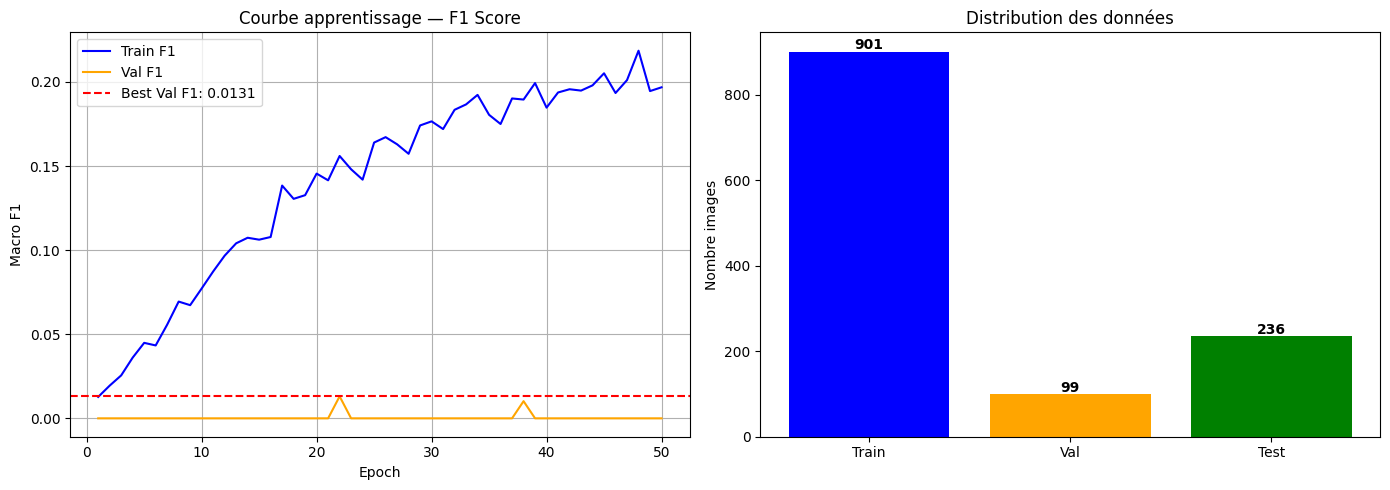


✅ Rapport et graphique sauvegardés !


In [13]:
# ═══════════════════════════════════════════
#  CELLULE 14 — Rapport du modèle (Bonus)
# ═══════════════════════════════════════════
report = {
    'Model Name'        : 'HybridNet-ResNet50',
    'Backbone'          : 'ResNet50 (from scratch, fine-tuned)',
    'Custom Modules'    : 'ChannelAttention (CBAM-style) + GeM Pooling + MLP Head',
    'Input Size'        : f'{CFG.IMG_SIZE}x{CFG.IMG_SIZE}',
    'Params (M)'        : f'{sum(p.numel() for p in model.parameters())/1e6:.1f}M',
    'Trainable Params'  : f'{sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f}M',
    'Optimizer'         : 'AdamW (lr=1e-3, wd=1e-4)',
    'LR Scheduler'      : f'CosineAnnealingLR (T_max={CFG.EPOCHS}, eta_min=1e-6)',
    'Loss'              : 'FocalLoss (gamma=2, class-weighted)',
    'Augmentations'     : 'RandomCrop, Flip, Rotation, ColorJitter, RandomGrayscale, RandomErasing',
    'Class Balancing'   : 'WeightedRandomSampler + class-weighted Focal Loss',
    'Mixed Precision'   : 'FP16 (torch.cuda.amp)',
    'Gradient Clipping' : 'max_norm=1.0',
    'Inference'         : 'TTA x3 (original + hflip + vflip)',
    'Best Val F1'       : f'{best_f1:.4f}',
    'Num Classes'       : NUM_CLASSES,
    'Train Samples'     : len(tr_df),
    'Val Samples'       : len(val_df),
}

print('\n' + '='*50)
print('         RAPPORT MODÈLE — HybridNet')
print('='*50)
for k, v in report.items():
    print(f'  {k:<22}: {v}')
print('='*50)

# Tableau Architecture (format compétition)
print('\n📋 Model Architecture Design Table:')
print(f'{"Model":<20} {"Backbone":<25} {"Custom Modules":<40} {"Params":<10} {"Input":<12} {"Trainable":<10}')
print('-'*120)
print(f'{"HybridNet":<20} {"ResNet50 (Finetuned)":<25} {"Attention + GeM + MLP Head":<40} {sum(p.numel() for p in model.parameters())/1e6:.1f}M{"":4} {"224x224":<12} {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f}M')

# Courbe d'apprentissage finale
import matplotlib.pyplot as plt
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_df['epoch'], hist_df['train_f1'], label='Train F1', color='blue')
axes[0].plot(hist_df['epoch'], hist_df['val_f1'],   label='Val F1',   color='orange')
axes[0].axhline(y=best_f1, color='red', linestyle='--', label=f'Best Val F1: {best_f1:.4f}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Courbe apprentissage — F1 Score')
axes[0].legend()
axes[0].grid(True)

axes[1].bar(['Train', 'Val', 'Test'], [len(tr_df), len(val_df), len(test_df)], color=['blue','orange','green'])
axes[1].set_title('Distribution des données')
axes[1].set_ylabel('Nombre images')
for i, v in enumerate([len(tr_df), len(val_df), len(test_df)]):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/rapport_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Rapport et graphique sauvegardés !')